## Bước 1: Kiểm tra GPU

In [104]:
import os
os.environ.setdefault('TORCHDYNAMO_DISABLE', '1')  # Tránh lỗi vòng import torch._dynamo trên một số môi trường

import torch

print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('TORCHDYNAMO_DISABLE =', os.environ.get('TORCHDYNAMO_DISABLE'))
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
else:
    print('WARNING: Không có GPU! Hãy vào Runtime > Change runtime type > GPU')

PyTorch version: 2.7.1+cu118
CUDA available: True
TORCHDYNAMO_DISABLE = 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.29 GB


## Bước 2: Cấu hình Google Drive (tùy chọn - để lưu model weights không bị mất)

In [105]:
# Kết nối Google Drive (Chỉ cần nếu bạn đã cài Google Drive for Desktop)
# Nếu chưa cài, hãy tải tại: https://www.google.com/drive/download/
# Sau khi cài, Google Drive sẽ xuất hiện như một ổ đĩa trên máy (ví dụ: G:\My Drive\)

import os

# === CẤU HÌNH ĐƯỜNG DẪN GOOGLE DRIVE ===
# Thay đổi đường dẫn này cho đúng với máy của bạn sau khi cài Google Drive Desktop
# Ví dụ: "G:\\My Drive\\U2Net_saved_models\\u2net\\"
DRIVE_SAVE_DIR = None  # Đặt None nếu chưa cài Google Drive Desktop

if DRIVE_SAVE_DIR and os.path.exists(os.path.dirname(DRIVE_SAVE_DIR)):
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
    print(f'Google Drive path OK: {DRIVE_SAVE_DIR}')
else:
    print('Google Drive Desktop chưa được cấu hình.')
    print('Model sẽ được lưu tại thư mục local. Bạn có thể upload lên Drive thủ công.')
    print('Hoặc cài Google Drive for Desktop: https://www.google.com/drive/download/')

Google Drive Desktop chưa được cấu hình.
Model sẽ được lưu tại thư mục local. Bạn có thể upload lên Drive thủ công.
Hoặc cài Google Drive for Desktop: https://www.google.com/drive/download/


## Bước 3: Kiểm tra thư mục project

In [106]:
import os

# Đường dẫn project trên máy local
PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
print(f'Project directory: {PROJECT_DIR}')
print(f'Nội dung thư mục:')
for item in os.listdir(PROJECT_DIR):
    print(f'  {item}')

Project directory: e:\AI_PBL\U-2-Net
Nội dung thư mục:
  .git
  .venv
  .vscode
  chạy code.txt
  clipping_camera.jpg
  data_loader.py
  figures
  gradio
  LICENSE
  model
  README.md
  requirements.txt
  saved_models
  setup_model_weights.py
  tempCodeRunnerFile.py
  test_data
  train_data
  U2Net_Colab_Train.ipynb
  U2Net_Colab_Train_3_loss.ipynb
  U2Net_Colab_Train_Hybrid_Loss.ipynb
  u2net_human_seg_test.py
  u2net_portrait_composite.py
  u2net_portrait_demo.py
  u2net_portrait_test.py
  u2net_test.py
  u2net_train.py
  val_data
  __pycache__


## Bước 4: Cài đặt thư viện

In [107]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image', 'pillow', 'numpy', 'scikit-learn', '-q'])
print('Cài đặt hoàn tất!')

Cài đặt hoàn tất!


## Bước 5: Tải dataset DUTS-TR

**Tùy chọn A:** Tải tự động (nếu link còn hoạt động)

**Tùy chọn B:** Upload thủ công từ máy tính của bạn

> Dataset DUTS-TR (~1.3GB) gồm ~10,000 ảnh training. Tải về từ: http://saliencydetection.net/duts/

In [108]:
# Bỏ qua bước này trên máy local - dataset đã có sẵn trong thư mục train_data/
print('Dataset đã có sẵn trên máy local, không cần tải.')

Dataset đã có sẵn trên máy local, không cần tải.


In [109]:
# Bỏ qua bước giải nén - dữ liệu đã được giải nén sẵn
print('Dữ liệu đã có sẵn tại train_data/DUTS/DUTS-TR/DUTS-TR/')

Dữ liệu đã có sẵn tại train_data/DUTS/DUTS-TR/DUTS-TR/


In [110]:
# Kiểm tra cấu trúc dataset
import glob
import os

data_base = os.path.join(PROJECT_DIR, 'train_data', 'DUTS', 'DUTS-TR', 'DUTS-TR')
train_imgs = glob.glob(os.path.join(data_base, 'im_aug', '*.jpg'))
train_lbls = glob.glob(os.path.join(data_base, 'gt_aug', '*.png'))

print(f'Số ảnh training tìm thấy: {len(train_imgs)}')
print(f'Số nhãn training tìm thấy: {len(train_lbls)}')

if len(train_imgs) == 0:
    print('\nWARNING: Không tìm thấy ảnh! Kiểm tra lại cấu trúc thư mục:')
    print(f'  {os.path.join(data_base, "im_aug", "*.jpg")}')
    print(f'  {os.path.join(data_base, "gt_aug", "*.png")}')
else:
    print('\nDataset OK!')

Số ảnh training tìm thấy: 10553
Số nhãn training tìm thấy: 10553

Dataset OK!


## Bước 6: Cấu hình và bắt đầu Training

In [111]:
import os
import torch
import torchvision
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
import numpy as np
import glob
import sys
import shutil

# Thêm đường dẫn project
sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

from data_loader import RescaleT, RandomCrop, RandomHFlip, RandomBrightContrast, RandomRotation, ToTensorLab, SalObjDataset
from model import U2NET, U2NETP

print('Import thành công!')

# Đường dẫn checkpoint local
LOCAL_CHECKPOINT_DIR = os.path.join(PROJECT_DIR, 'saved_models', 'u2net')
os.makedirs(LOCAL_CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint local dir: {LOCAL_CHECKPOINT_DIR}')

Import thành công!
Checkpoint local dir: e:\AI_PBL\U-2-Net\saved_models\u2net


In [ ]:

MODEL_NAME   = 'u2net'   # 'u2net' (nặng, chính xác hơn) hoặc 'u2netp' (nhẹ, nhanh hơn)
EPOCH_NUM    = 40        # Số epoch
BATCH_SIZE   = 2        # Đã giảm xuống 1 để tránh lỗi CUDA Out of Memory
LR           = 0.0001     # Learning rate (giữ nguyên như original training)
WEIGHT_DECAY = 1e-4      # L2 regularization để chống overfitting
SAVE_FRQ     = 20000       # Lưu model mỗi N iterations
RESUME_CKPT  = os.path.join(PROJECT_DIR, 'saved_models', 'u2net', 'u2net_stopped_at_iter_88263.pth')  # Đường dẫn checkpoint để resume (đặt None nếu không resume)
SAVE_EPOCH_FRQ = 5        # Lưu model mỗi N epochs

# === ANTI-OVERFITTING CONFIG ===
PATIENCE     = 7         # Early stopping: dừng nếu val loss không giảm sau N epochs

# =============================================================
# === CHỌN SCHEDULER: 'cosine' hoặc 'plateau' ================
# =============================================================
# 'cosine'  -> CosineAnnealingLR: giảm LR theo hàm cosine, phù hợp fine-tuning ổn định
# 'plateau' -> ReduceLROnPlateau: giảm LR khi val loss không giảm, phản ứng nhanh khi overfitting
SCHEDULER_TYPE = 'plateau'   # <<< ĐỔI GIÁ TRỊ NÀY ĐỂ THỬ SCHEDULER KHÁC

# --- Tham số CosineAnnealingLR (chỉ dùng khi SCHEDULER_TYPE = 'cosine') ---
COSINE_T_MAX = 10        # Chu kỳ cosine (số epochs cho 1 nửa chu kỳ)
COSINE_ETA_MIN = 1e-6    # LR tối thiểu của cosine

# --- Tham số ReduceLROnPlateau (chỉ dùng khi SCHEDULER_TYPE = 'plateau') ---
SCHEDULER_PATIENCE = 3   # Giảm LR nếu val loss không giảm sau N epochs
SCHEDULER_FACTOR = 0.5   # Hệ số giảm LR (LR mới = LR cũ * factor)
SCHEDULER_MIN_LR = 1e-6  # LR tối thiểu

# Dataset - Đường dẫn LOCAL
DATA_DIR      = os.path.join(PROJECT_DIR, 'train_data', 'DUTS') + os.sep
TRA_IMAGE_DIR = os.path.join('DUTS-TR', 'DUTS-TR', 'im_aug') + os.sep
TRA_LABEL_DIR = os.path.join('DUTS-TR', 'DUTS-TR', 'gt_aug') + os.sep

# Thư mục lưu model LOCAL
MODEL_DIR = LOCAL_CHECKPOINT_DIR
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Model:      {MODEL_NAME}')
print(f'Epochs:     {EPOCH_NUM}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Weight decay: {WEIGHT_DECAY}')
print(f'Early stopping patience: {PATIENCE} epochs')
print(f'>>> Scheduler đang dùng: {SCHEDULER_TYPE.upper()}')
if SCHEDULER_TYPE == 'cosine':
    print(f'    CosineAnnealingLR: T_max={COSINE_T_MAX}, eta_min={COSINE_ETA_MIN}')
else:
    print(f'    ReduceLROnPlateau: patience={SCHEDULER_PATIENCE}, factor={SCHEDULER_FACTOR}, min_lr={SCHEDULER_MIN_LR}')
print(f'Save dir (local):  {MODEL_DIR}')
if DRIVE_SAVE_DIR:
    print(f'Save dir (Drive):  {DRIVE_SAVE_DIR}')
    print(f'Lưu vào Drive mỗi {SAVE_EPOCH_FRQ} epochs')
else:
    print(f'Google Drive chưa cấu hình - chỉ lưu local')
    print(f'Lưu checkpoint mỗi {SAVE_EPOCH_FRQ} epochs')
print(f'Resume:     {RESUME_CKPT}')
print(f'File tồn tại: {os.path.exists(RESUME_CKPT)}')

Model:      u2net
Epochs:     40
Batch size: 2
Weight decay: 0.0001
Early stopping patience: 7 epochs
>>> Scheduler đang dùng: PLATEAU
    ReduceLROnPlateau: patience=3, factor=0.5, min_lr=1e-06
Save dir (local):  e:\AI_PBL\U-2-Net\saved_models\u2net
Google Drive chưa cấu hình - chỉ lưu local
Lưu checkpoint mỗi 5 epochs
Resume:     e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_stopped_at_iter_77032.pth
File tồn tại: True


### Tách dữ liệu thành Training và Validation Sets (Tùy chọn)

Nếu bạn muốn theo dõi hiệu suất của mô hình trên một tập dữ liệu validation riêng biệt để đánh giá overfitting, bạn có thể thực hiện việc tách dữ liệu như sau. Điều này sẽ giúp bạn hiểu rõ hơn về khả năng tổng quát hóa của mô hình.

In [113]:
import glob
import os
from sklearn.model_selection import train_test_split

# Lấy danh sách ảnh và nhãn DUTS-TR từ thư mục train_data
full_image_path_pattern = os.path.join(DATA_DIR, TRA_IMAGE_DIR, '*.jpg')
full_label_path_pattern = os.path.join(DATA_DIR, TRA_LABEL_DIR, '*.png')

print(f'Kiểm tra đường dẫn ảnh: {full_image_path_pattern}')
print(f'Kiểm tra đường dẫn nhãn: {full_label_path_pattern}')

# Kiểm tra thư mục ảnh có tồn tại và chứa file không
image_dir_for_ls = os.path.dirname(full_image_path_pattern)
print(f'\nNội dung thư mục ảnh ({image_dir_for_ls}):')
if os.path.exists(image_dir_for_ls):
    files = os.listdir(image_dir_for_ls)
    print(f'  Tổng: {len(files)} files')
    for f in files[:5]:
        print(f'  {f}')
else:
    print(f'  KHÔNG TỒN TẠI!')

tra_img_name_list = sorted(glob.glob(full_image_path_pattern))
tra_lbl_name_list = []
for img_path in tra_img_name_list:
    img_name = os.path.basename(img_path)
    imidx = os.path.splitext(img_name)[0]
    tra_lbl_name_list.append(os.path.join(DATA_DIR, TRA_LABEL_DIR, imidx + '.png'))

print(f'\nSố ảnh DUTS-TR tìm thấy: {len(tra_img_name_list)}')
print(f'Số nhãn DUTS-TR tìm thấy: {len(tra_lbl_name_list)}')

if not tra_img_name_list:
    print('\nWARNING: Không tìm thấy ảnh! Vui lòng kiểm tra lại đường dẫn DATA_DIR, TRA_IMAGE_DIR, TRA_LABEL_DIR.')
    raise ValueError("Không tìm thấy ảnh training. Vui lòng kiểm tra lại dataset.")

# Dùng full DUTS-TR để train
train_img_list = list(tra_img_name_list)
train_lbl_list = list(tra_lbl_name_list)

# Tìm DUTS-TE trong thư mục val_data
val_img_list = []
val_lbl_list = []
val_base = os.path.join(PROJECT_DIR, 'val_data', 'DUTS-TE')
if os.path.isdir(val_base):
    print(f'\nĐã tìm thấy DUTS-TE trong: {val_base}')
    img_dir_candidates = ['DUTS-TE-Image', 'DUTS-TE-Imgs', 'images', 'image', 'img', 'im', 'im_aug']
    lbl_dir_candidates = ['DUTS-TE-Mask', 'DUTS-TE-Masks', 'gt', 'gt_aug', 'labels', 'label', 'mask', 'masks']

    val_image_dir = None
    for candidate in img_dir_candidates:
        candidate_path = os.path.join(val_base, candidate)
        if os.path.isdir(candidate_path):
            val_image_dir = candidate_path
            break

    val_label_dir = None
    for candidate in lbl_dir_candidates:
        candidate_path = os.path.join(val_base, candidate)
        if os.path.isdir(candidate_path):
            val_label_dir = candidate_path
            break

    if val_image_dir and val_label_dir:
        val_img_list = sorted(glob.glob(os.path.join(val_image_dir, '*.jpg')))
        for img_path in val_img_list:
            img_name = os.path.basename(img_path)
            imidx = os.path.splitext(img_name)[0]
            val_lbl_list.append(os.path.join(val_label_dir, imidx + '.png'))

        missing = [p for p in val_lbl_list if not os.path.exists(p)]
        if missing:
            print(f'WARNING: {len(missing)} file label DUTS-TE không tồn tại. Sẽ dùng random split 20% từ DUTS-TR.')
            val_img_list = []
            val_lbl_list = []
        else:
            print(f'Đã dùng DUTS-TE cho validation: {len(val_img_list)} ảnh')
    else:
        print('WARNING: Không tìm thấy thư mục ảnh hoặc nhãn DUTS-TE trong val_data. Sẽ dùng random split 20% từ DUTS-TR.')
else:
    print('WARNING: Không tìm thấy thư mục val_data/DUTS-TE. Sẽ dùng random split 20% từ DUTS-TR.')

if not val_img_list:
    # fallback: tách ngẫu nhiên từ DUTS-TR nếu DUTS-TE không có hoặc thiếu nhãn
    paired_data = list(zip(tra_img_name_list, tra_lbl_name_list))
    train_pairs, val_pairs = train_test_split(paired_data, test_size=0.2, random_state=42)
    train_img_list, train_lbl_list = zip(*train_pairs)
    val_img_list, val_lbl_list = zip(*val_pairs)
    train_img_list = list(train_img_list)
    train_lbl_list = list(train_lbl_list)
    val_img_list = list(val_img_list)
    val_lbl_list = list(val_lbl_list)
    print(f'Random split: Train {len(train_img_list)} | Validation {len(val_img_list)}')
else:
    train_img_list = list(train_img_list)
    train_lbl_list = list(train_lbl_list)

print(f'\nSố ảnh training dùng thực tế: {len(train_img_list)}')
print(f'Số ảnh validation dùng thực tế: {len(val_img_list)}')

# DataLoader cho tập train - GIỐNG ORIGINAL TRAINING (RescaleT + RandomCrop)
# Lưu ý: RandomCrop trong data_loader.py ĐÃ CÓ SẴN random horizontal flip
salobj_dataset_train = SalObjDataset(
    img_name_list=train_img_list,
    lbl_name_list=train_lbl_list,
    transform=transforms.Compose([
        RescaleT(320),
        RandomCrop(256),
        ToTensorLab(flag=0)
    ])
)
salobj_dataloader_train = DataLoader(
    salobj_dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# DataLoader cho tập validation - KHÔNG augmentation
salobj_dataset_val = SalObjDataset(
    img_name_list=val_img_list,
    lbl_name_list=val_lbl_list,
    transform=transforms.Compose([
        RescaleT(320),
        ToTensorLab(flag=0)
    ])
)
salobj_dataloader_val = DataLoader(
    salobj_dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print('DataLoader cho Training và Validation đã sẵn sàng!')
print('Train: full DUTS-TR')
print('Validation: DUTS-TE nếu tìm thấy, ngược lại random split 20% từ DUTS-TR')

Kiểm tra đường dẫn ảnh: e:\AI_PBL\U-2-Net\train_data\DUTS\DUTS-TR\DUTS-TR\im_aug\*.jpg
Kiểm tra đường dẫn nhãn: e:\AI_PBL\U-2-Net\train_data\DUTS\DUTS-TR\DUTS-TR\gt_aug\*.png

Nội dung thư mục ảnh (e:\AI_PBL\U-2-Net\train_data\DUTS\DUTS-TR\DUTS-TR\im_aug):
  Tổng: 10553 files
  ILSVRC2012_test_00000004.jpg
  ILSVRC2012_test_00000018.jpg
  ILSVRC2012_test_00000019.jpg
  ILSVRC2012_test_00000022.jpg
  ILSVRC2012_test_00000030.jpg

Số ảnh DUTS-TR tìm thấy: 10553
Số nhãn DUTS-TR tìm thấy: 10553

Đã tìm thấy DUTS-TE trong: e:\AI_PBL\U-2-Net\val_data\DUTS-TE
Đã dùng DUTS-TE cho validation: 5019 ảnh

Số ảnh training dùng thực tế: 10553
Số ảnh validation dùng thực tế: 5019
DataLoader cho Training và Validation đã sẵn sàng!
Train: full DUTS-TR
Validation: DUTS-TE nếu tìm thấy, ngược lại random split 20% từ DUTS-TR


In [114]:
# ------- 0. Giải phóng GPU memory --------
import gc
try:
    del net
except:
    pass
try:
    del optimizer
except:
    pass
try:
    del scheduler
except:
    pass
gc.collect()
try:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(f'GPU memory đã giải phóng. Free: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB / {torch.cuda.mem_get_info()[1]/1e9:.2f} GB')
except RuntimeError:
    print('WARNING: Không thể giải phóng GPU memory. Hãy Restart Kernel rồi chạy lại từ Cell 1.')
    raise SystemExit('Restart Kernel required!')

# ------- 1. define loss functions (Hybrid: BCE + SSIM + IoU) --------

# Trọng số cho Hybrid Loss — có thể tinh chỉnh
W_BCE  = 1.0   # trọng số BCE
W_SSIM = 1.0   # trọng số SSIM
W_IOU  = 1.0   # trọng số IoU

# ── SSIM Loss ──────────────────────────────────────────────────────────
class SSIMLoss(nn.Module):
    """Structural Similarity Loss (1 - SSIM)."""
    def __init__(self, window_size: int = 11, sigma: float = 1.5):
        super().__init__()
        self.window_size = window_size
        self.window = self._create_window(window_size, sigma)  # (1,1,k,k)

    @staticmethod
    def _gaussian(window_size: int, sigma: float):
        coords = torch.arange(window_size, dtype=torch.float32) - window_size // 2
        g = torch.exp(-coords ** 2 / (2 * sigma ** 2))
        return g / g.sum()

    def _create_window(self, window_size: int, sigma: float):
        _1d = self._gaussian(window_size, sigma).unsqueeze(1)   # (k,1)
        _2d = _1d.mm(_1d.t()).unsqueeze(0).unsqueeze(0)         # (1,1,k,k)
        return _2d

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # pred & target đã ở [0,1], shape (B,1,H,W)
        win = self.window.to(pred.device)
        pad = self.window_size // 2
        mu1 = F.conv2d(pred,   win, padding=pad)
        mu2 = F.conv2d(target, win, padding=pad)
        mu1_sq, mu2_sq = mu1 ** 2, mu2 ** 2
        mu1_mu2 = mu1 * mu2
        sigma1_sq = F.conv2d(pred * pred,     win, padding=pad) - mu1_sq
        sigma2_sq = F.conv2d(target * target, win, padding=pad) - mu2_sq
        sigma12   = F.conv2d(pred * target,   win, padding=pad) - mu1_mu2
        C1, C2 = 0.01 ** 2, 0.03 ** 2
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        return 1.0 - ssim_map.mean()


# ── IoU Loss ───────────────────────────────────────────────────────────
class IoULoss(nn.Module):
    """Soft IoU Loss (1 - IoU) — hoạt động trên logits hoặc prob."""
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # Áp sigmoid để chuyển logit -> prob nếu pred chưa qua sigmoid
        prob = torch.sigmoid(pred)
        inter = (prob * target).sum(dim=(2, 3))
        union = (prob + target - prob * target).sum(dim=(2, 3))
        iou   = (inter + self.smooth) / (union + self.smooth)
        return 1.0 - iou.mean()


# ── Hybrid Loss = BCE + SSIM + IoU ────────────────────────────────────
class HybridLoss(nn.Module):
    """
    Hybrid Loss = w_bce * BCE + w_ssim * SSIM + w_iou * IoU
    Đầu vào pred: xác suất [0,1] (U2Net đã qua sigmoid).
    """
    def __init__(self, w_bce: float = 1.0, w_ssim: float = 1.0, w_iou: float = 1.0):
        super().__init__()
        self.bce  = nn.BCELoss(size_average=True)
        self.ssim = SSIMLoss()
        self.iou  = IoULoss()
        self.w_bce, self.w_ssim, self.w_iou = w_bce, w_ssim, w_iou

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # pred đã ở [0,1] (U2Net output đã sigmoid)
        l_bce  = self.bce(pred, target)
        l_ssim = self.ssim(pred, target)
        # IoULoss tự gọi sigmoid bên trong nên truyền pred gốc (~ logit)
        # U2Net output đã là prob, nên cần clamp để tránh sigmoid(sigmoid(x))
        # → truyền pred thẳng vào IoULoss nhưng bỏ sigmoid bên trong
        inter = (pred * target).sum(dim=(2, 3))
        union = (pred + target - pred * target).sum(dim=(2, 3))
        l_iou = 1.0 - ((inter + 1e-6) / (union + 1e-6)).mean()
        return self.w_bce * l_bce + self.w_ssim * l_ssim + self.w_iou * l_iou


hybrid_loss = HybridLoss(w_bce=W_BCE, w_ssim=W_SSIM, w_iou=W_IOU)

# Giữ lại bce_loss để dùng riêng trong phần validation (tính val loss theo BCE thuần)
bce_loss = nn.BCELoss(size_average=True)


def muti_hybrid_loss_fusion(d0, d1, d2, d3, d4, d5, d6, labels_v):
    """Hybrid loss trên 7 outputs của U2Net."""
    loss0 = hybrid_loss(d0, labels_v)
    loss1 = hybrid_loss(d1, labels_v)
    loss2 = hybrid_loss(d2, labels_v)
    loss3 = hybrid_loss(d3, labels_v)
    loss4 = hybrid_loss(d4, labels_v)
    loss5 = hybrid_loss(d5, labels_v)
    loss6 = hybrid_loss(d6, labels_v)
    loss  = loss0 + loss1 + loss2 + loss3 + loss4 + loss5 + loss6
    print("l0: %3f, l1: %3f, l2: %3f, l3: %3f, l4: %3f, l5: %3f, l6: %3f" % (
        loss0.item(), loss1.item(), loss2.item(), loss3.item(),
        loss4.item(), loss5.item(), loss6.item()))
    return loss0, loss


print(f'Hybrid Loss đã khởi tạo: BCE(x{W_BCE}) + SSIM(x{W_SSIM}) + IoU(x{W_IOU})')

# ------- 2. define model --------
if MODEL_NAME == 'u2net':
    net = U2NET(3, 1)
elif MODEL_NAME == 'u2netp':
    net = U2NETP(3, 1)

if torch.cuda.is_available():
    net.cuda()
    print(f'Model đang chạy trên: {torch.cuda.get_device_name(0)}')
    print(f'GPU memory sau khi load model: {torch.cuda.memory_allocated()/1e9:.2f} GB used')
else:
    print('WARNING: Đang chạy trên CPU! Training sẽ rất chậm.')

# ------- 3. define optimizer + scheduler --------
print("---define optimizer...")

def _build_adam_with_dynamo_fallback(model):
    """Tạo Adam optimizer và fallback nếu lỗi torch._dynamo circular import."""
    try:
        return optim.Adam(
            model.parameters(),
            lr=LR,
            betas=(0.9, 0.999),
            eps=1e-08,
            weight_decay=WEIGHT_DECAY,
        )
    except AttributeError as e:
        if 'torch._dynamo' not in str(e):
            raise

        print('WARNING: Lỗi torch._dynamo khi tạo optimizer. Áp dụng fallback disable dynamo...')

        if hasattr(torch.optim.Optimizer.add_param_group, '__wrapped__'):
            torch.optim.Optimizer.add_param_group = torch.optim.Optimizer.add_param_group.__wrapped__
            print('  Đã bypass wrapper torch._dynamo trong Optimizer.add_param_group.')

        try:
            return optim.Adam(
                model.parameters(),
                lr=LR,
                betas=(0.9, 0.999),
                eps=1e-08,
                weight_decay=WEIGHT_DECAY,
            )
        except Exception as e2:
            raise RuntimeError(
                'Không thể tạo optimizer do môi trường PyTorch bị lỗi. '
                'Khuyến nghị: restart kernel, sau đó cài lại torch + torchvision tương thích.'
            ) from e2

optimizer = _build_adam_with_dynamo_fallback(net)
print(f'  Weight decay (L2 reg): {WEIGHT_DECAY}')

# Tạo scheduler dựa trên SCHEDULER_TYPE
if SCHEDULER_TYPE == 'cosine':
    scheduler = CosineAnnealingLR(optimizer, T_max=COSINE_T_MAX, eta_min=COSINE_ETA_MIN)
    print(f'  Scheduler: CosineAnnealingLR (T_max={COSINE_T_MAX}, eta_min={COSINE_ETA_MIN})')
elif SCHEDULER_TYPE == 'plateau':
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=SCHEDULER_FACTOR,
                                   patience=SCHEDULER_PATIENCE, min_lr=SCHEDULER_MIN_LR)
    print(f'  Scheduler: ReduceLROnPlateau (patience={SCHEDULER_PATIENCE}, factor={SCHEDULER_FACTOR}, min_lr={SCHEDULER_MIN_LR})')
else:
    raise ValueError(f"SCHEDULER_TYPE không hợp lệ: '{SCHEDULER_TYPE}'. Chọn 'cosine' hoặc 'plateau'.")

# ------- 4. load checkpoint nếu có --------
start_epoch = 0
ite_num = 0
checkpoint = None
train_losses_per_epoch = []
val_losses_per_epoch = []
best_val_loss = float('inf')
early_stop_counter = 0

# === METRIC HISTORY ===
mae_per_epoch = []
maxF_per_epoch = []
sm_per_epoch = []
lr_per_epoch = []

LOAD_OPTIMIZER_STATE = True

def _sanitize_history(values):
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        values = values.tolist()
    elif isinstance(values, tuple):
        values = list(values)

    # Hỗ trợ checkpoint cũ lưu dạng lồng: [[...]]
    if isinstance(values, list) and len(values) == 1 and isinstance(values[0], (list, tuple, np.ndarray)):
        values = np.asarray(values[0]).reshape(-1).tolist()

    out = []
    for v in values:
        if np.isscalar(v):
            out.append(float(v))
    return out

if RESUME_CKPT:
    if os.path.exists(RESUME_CKPT):
        checkpoint = torch.load(RESUME_CKPT, map_location='cpu')
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            net.load_state_dict(checkpoint['model_state_dict'])
            start_epoch = checkpoint.get('epoch', 0)
            ite_num = checkpoint.get('ite_num', 0)
            train_losses_per_epoch = _sanitize_history(checkpoint.get('train_losses_per_epoch', []))
            val_losses_per_epoch = _sanitize_history(checkpoint.get('val_losses_per_epoch', []))
            mae_per_epoch = _sanitize_history(checkpoint.get('mae_per_epoch', []))
            maxF_per_epoch = _sanitize_history(checkpoint.get('maxF_per_epoch', []))
            sm_per_epoch = _sanitize_history(checkpoint.get('sm_per_epoch', []))
            lr_per_epoch = _sanitize_history(checkpoint.get('lr_per_epoch', []))

            if val_losses_per_epoch:
                best_val_loss = min(val_losses_per_epoch)
                print(f'  Best val loss từ checkpoint: {best_val_loss:.4f}')

            if LOAD_OPTIMIZER_STATE and 'optimizer_state_dict' in checkpoint:
                optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
                print(f'Đã load optimizer state (giữ momentum). LR từ checkpoint: {optimizer.param_groups[0]["lr"]}')
            else:
                print(f'Dùng optimizer MỚI với LR = {LR} (không load state cũ)')

            if SCHEDULER_TYPE == 'cosine':
                for _ in range(start_epoch):
                    scheduler.step()

            print(f'Đã load checkpoint: {RESUME_CKPT} (Epoch {start_epoch}, Iter {ite_num})')
        else:
            net.load_state_dict(checkpoint)
            print(f'Đã load trọng số model từ: {RESUME_CKPT}')
    else:
        print(f'LỖI: Không tìm thấy file tại {RESUME_CKPT}')
else:
    print('Bắt đầu training từ đầu (không có checkpoint).')

print(f'Optimizer LR: {optimizer.param_groups[0]["lr"]}')
print(f'Early stopping patience: {PATIENCE} epochs')
print(f'Scheduler: {SCHEDULER_TYPE.upper()}')
print('Model và Optimizer sẵn sàng!')


GPU memory đã giải phóng. Free: 2.85 GB / 4.29 GB
Hybrid Loss đã khởi tạo: BCE(x1.0) + SSIM(x1.0) + IoU(x1.0)
Model đang chạy trên: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory sau khi load model: 0.73 GB used
---define optimizer...
  Weight decay (L2 reg): 0.0001
  Scheduler: ReduceLROnPlateau (patience=3, factor=0.5, min_lr=1e-06)
  Best val loss từ checkpoint: 8.0394
Đã load optimizer state (giữ momentum). LR từ checkpoint: 0.0001
Đã load checkpoint: e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_stopped_at_iter_77032.pth (Epoch 18, Iter 77032)
Optimizer LR: 0.0001
Early stopping patience: 7 epochs
Scheduler: PLATEAU
Model và Optimizer sẵn sàng!


In [115]:
# ------- 5. training process --------
import numpy as np
import matplotlib.pyplot as plt

print("---start training...")
print(f"Fine-tuning với Scheduler: {SCHEDULER_TYPE.upper()}")
print(f"Train: 80% | Validation: 20%")
print(f"Anti-overfitting: weight_decay={WEIGHT_DECAY}, LR scheduler ({SCHEDULER_TYPE}), early stopping (patience={PATIENCE}), data augmentation")

train_num = len(train_img_list)
val_num = len(val_img_list)

ite_num = ite_num  # giữ từ checkpoint nếu có
running_loss = 0.0
running_tar_loss = 0.0
ite_num4val = 0
save_frq = SAVE_FRQ  # save the model every N iterations

fig_dir = os.path.join(PROJECT_DIR, 'figures')
os.makedirs(fig_dir, exist_ok=True)

def save_checkpoint_to_drive(filename):
    """Copy checkpoint lên Google Drive nếu đã cấu hình"""
    if DRIVE_SAVE_DIR:
        try:
            drive_path = os.path.join(DRIVE_SAVE_DIR, filename)
            shutil.copy2(os.path.join(MODEL_DIR, filename), drive_path)
            print(f'  >>> Đã copy lên Google Drive: {drive_path}')
        except Exception as e:
            print(f'  >>> LỖI khi copy lên Drive: {e}')

def _save_training_figures():
    def _to_1d_float_list(values):
        if values is None:
            return []
        if isinstance(values, np.ndarray):
            values = values.tolist()
        elif isinstance(values, tuple):
            values = list(values)

        # Một số checkpoint cũ có thể lưu dạng lồng: [[v1, v2, ...]]
        if len(values) == 1 and isinstance(values[0], (list, tuple, np.ndarray)):
            values = np.asarray(values[0]).reshape(-1).tolist()

        flat = []
        for v in values:
            if np.isscalar(v):
                flat.append(float(v))
        return flat

    train_hist = _to_1d_float_list(train_losses_per_epoch)
    val_hist = _to_1d_float_list(val_losses_per_epoch)
    mae_hist = _to_1d_float_list(mae_per_epoch)
    maxf_hist = _to_1d_float_list(maxF_per_epoch)
    sm_hist = _to_1d_float_list(sm_per_epoch)
    lr_hist = _to_1d_float_list(lr_per_epoch)

    if len(train_hist) == 0:
        return

    x_epochs = list(range(1, len(train_hist) + 1))

    # Figure 1: Loss
    fig1, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(x_epochs, train_hist, label='Train Loss', linewidth=2)
    if len(val_hist) > 0:
        ax1.plot(range(1, len(val_hist) + 1), val_hist, label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.35)
    if len(val_hist) > 0:
        best_epoch_idx = int(np.argmin(val_hist)) + 1
        ax1.axvline(x=best_epoch_idx, linestyle='--', color='red', label=f'Best Epoch ({best_epoch_idx})')
        ax1.scatter(best_epoch_idx, val_hist[best_epoch_idx - 1], color='red', zorder=5)
    ax1.legend(loc='upper right')
    ax1.set_title('Loss Curve')
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, 'u2net_loss_curve.png'), dpi=220)
    plt.close(fig1)

    # Figure 2: Metrics
    fig2, axes = plt.subplots(1, 2, figsize=(14, 4))
    if len(maxf_hist) > 0:
        axes[0].plot(range(1, len(maxf_hist) + 1), maxf_hist, label='maxFβ', marker='o', markersize=4)
    if len(sm_hist) > 0:
        axes[0].plot(range(1, len(sm_hist) + 1), sm_hist, label='S-measure (proxy)', marker='s', markersize=4)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Score (higher is better)')
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.35)
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].set_title('Segmentation Metrics (higher ↑)')

    if len(mae_hist) > 0:
        axes[1].plot(range(1, len(mae_hist) + 1), mae_hist, label='MAE', color='tomato', marker='o', markersize=4)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (lower is better)')
    axes[1].grid(True, alpha=0.35)
    axes[1].legend(loc='upper right', fontsize=9)
    axes[1].set_title('Mean Absolute Error (lower ↓)')

    plt.suptitle('U2Net Evaluation Metrics (Training-time)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, 'u2net_metrics_curve.png'), dpi=220, bbox_inches='tight')
    plt.close(fig2)

    # Figure 3: Learning rate
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    if len(lr_hist) > 0:
        ax3.plot(range(1, len(lr_hist) + 1), lr_hist, linewidth=2, label='Learning Rate')
        ax3.set_yscale('log')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('LR')
    ax3.grid(True, alpha=0.35)
    ax3.legend(loc='upper right')
    ax3.set_title('Learning Rate Schedule')
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, 'u2net_lr_schedule.png'), dpi=220)
    plt.close(fig3)

for epoch in range(start_epoch, EPOCH_NUM):
    net.train()

    epoch_train_loss = 0.0
    epoch_train_tar_loss = 0.0
    epoch_batch_count = 0

    for i, data in enumerate(salobj_dataloader_train):
        ite_num = ite_num + 1
        ite_num4val = ite_num4val + 1

        inputs, labels = data['image'], data['label']
        inputs = inputs.type(torch.FloatTensor)
        labels = labels.type(torch.FloatTensor)

        if torch.cuda.is_available():
            inputs_v, labels_v = Variable(inputs.cuda(), requires_grad=False), Variable(labels.cuda(), requires_grad=False)
        else:
            inputs_v, labels_v = Variable(inputs, requires_grad=False), Variable(labels, requires_grad=False)

        optimizer.zero_grad()

        d0, d1, d2, d3, d4, d5, d6 = net(inputs_v)
        loss2, loss = muti_hybrid_loss_fusion(d0, d1, d2, d3, d4, d5, d6, labels_v)

        loss.backward()
        optimizer.step()

        running_loss += loss.data.item()
        running_tar_loss += loss2.data.item()

        epoch_train_loss += loss.data.item()
        epoch_train_tar_loss += loss2.data.item()
        epoch_batch_count += 1

        del d0, d1, d2, d3, d4, d5, d6, loss2, loss

        print("[epoch: %3d/%3d, batch: %5d/%5d, ite: %d] train loss: %3f, tar: %3f " % (
            epoch + 1, EPOCH_NUM, (i + 1) * BATCH_SIZE, train_num, ite_num,
            running_loss / ite_num4val, running_tar_loss / ite_num4val))

        if ite_num % save_frq == 0:
            ckpt_name = MODEL_NAME + "_hybrid_itr_%d_train_%3f_tar_%3f.pth" % (
                ite_num, running_loss / ite_num4val, running_tar_loss / ite_num4val)
            torch.save(net.state_dict(), os.path.join(MODEL_DIR, ckpt_name))
            print(f'  >>> Saved: {ckpt_name}')
            running_loss = 0.0
            running_tar_loss = 0.0
            net.train()
            ite_num4val = 0

    avg_train_loss = epoch_train_loss / epoch_batch_count if epoch_batch_count > 0 else 0.0
    avg_train_tar = epoch_train_tar_loss / epoch_batch_count if epoch_batch_count > 0 else 0.0
    train_losses_per_epoch.append(avg_train_loss)

    # --- Validation sau mỗi epoch ---
    net.eval()
    val_loss_sum = 0.0
    val_tar_sum = 0.0
    val_batch_count = 0

    # Training-time metrics (nhanh)
    mae_sum = 0.0
    f_sum = 0.0

    with torch.no_grad():
        for i_val, data_val in enumerate(salobj_dataloader_val):
            inputs_val, labels_val = data_val['image'], data_val['label']
            inputs_val = inputs_val.type(torch.FloatTensor)
            labels_val = labels_val.type(torch.FloatTensor)

            if torch.cuda.is_available():
                inputs_v_val = Variable(inputs_val.cuda(), requires_grad=False)
                labels_v_val = Variable(labels_val.cuda(), requires_grad=False)
            else:
                inputs_v_val = Variable(inputs_val, requires_grad=False)
                labels_v_val = Variable(labels_val, requires_grad=False)

            d0_v, d1_v, d2_v, d3_v, d4_v, d5_v, d6_v = net(inputs_v_val)
            loss2_v = hybrid_loss(d0_v, labels_v_val)
            loss_v = hybrid_loss(d0_v, labels_v_val) + hybrid_loss(d1_v, labels_v_val) + hybrid_loss(d2_v, labels_v_val) + \
                     hybrid_loss(d3_v, labels_v_val) + hybrid_loss(d4_v, labels_v_val) + hybrid_loss(d5_v, labels_v_val) + \
                     hybrid_loss(d6_v, labels_v_val)

            val_loss_sum += loss_v.data.item()
            val_tar_sum += loss2_v.data.item()
            val_batch_count += 1

            # MAE thực
            mae_sum += torch.mean(torch.abs(d0_v - labels_v_val)).item()

            # maxF proxy tại threshold 0.5 (nhanh hơn full 255 thresholds)
            pred_bin = (d0_v >= 0.5).float()
            gt_bin = (labels_v_val >= 0.5).float()
            tp = (pred_bin * gt_bin).sum().item()
            prec = tp / (pred_bin.sum().item() + 1e-8)
            rec = tp / (gt_bin.sum().item() + 1e-8)
            f_val = (1 + 0.3) * prec * rec / (0.3 * prec + rec + 1e-8)
            f_sum += f_val

            del d0_v, d1_v, d2_v, d3_v, d4_v, d5_v, d6_v

    avg_val_loss = val_loss_sum / val_batch_count if val_batch_count > 0 else 0.0
    avg_val_tar = val_tar_sum / val_batch_count if val_batch_count > 0 else 0.0
    val_losses_per_epoch.append(avg_val_loss)

    epoch_mae = mae_sum / val_batch_count if val_batch_count > 0 else 0.0
    epoch_maxf = f_sum / val_batch_count if val_batch_count > 0 else 0.0
    epoch_sm_proxy = max(0.0, min(1.0, 1.0 - epoch_mae))

    mae_per_epoch.append(epoch_mae)
    maxF_per_epoch.append(epoch_maxf)
    sm_per_epoch.append(epoch_sm_proxy)

    # === SCHEDULER STEP ===
    lr_before = optimizer.param_groups[0]['lr']
    if SCHEDULER_TYPE == 'cosine':
        scheduler.step()
    elif SCHEDULER_TYPE == 'plateau':
        scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_per_epoch.append(current_lr)

    print(f'  [Scheduler {SCHEDULER_TYPE.upper()}] LR: {lr_before:.2e} -> {current_lr:.2e}')
    print("\n" + "=" * 70)
    print("[Epoch %3d/%3d Summary] Train Loss: %.4f, Train Tar: %.4f | Val Loss: %.4f, Val Tar: %.4f | LR: %.2e" % (
        epoch + 1, EPOCH_NUM, avg_train_loss, avg_train_tar, avg_val_loss, avg_val_tar, current_lr))
    print(f"  [Metrics] MAE={epoch_mae:.4f} | maxF(proxy)={epoch_maxf:.4f} | Sm(proxy)={epoch_sm_proxy:.4f}")

    # === EARLY STOPPING + SAVE BEST MODEL ===
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
        best_name = f'{MODEL_NAME}_best.pth'
        best_path = os.path.join(MODEL_DIR, best_name)
        torch.save({
            'epoch': epoch + 1,
            'ite_num': ite_num,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_type': SCHEDULER_TYPE,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'train_losses_per_epoch': train_losses_per_epoch,
            'val_losses_per_epoch': val_losses_per_epoch,
            'mae_per_epoch': mae_per_epoch,
            'maxF_per_epoch': maxF_per_epoch,
            'sm_per_epoch': sm_per_epoch,
            'lr_per_epoch': lr_per_epoch,
        }, best_path)
        print(f'  >>> NEW BEST MODEL saved! Val Loss: {avg_val_loss:.4f} (Epoch {epoch+1})')
        save_checkpoint_to_drive(best_name)
    else:
        early_stop_counter += 1
        print(f'  >>> Val Loss không cải thiện ({early_stop_counter}/{PATIENCE})')

    _save_training_figures()

    print("=" * 70 + "\n")

    if early_stop_counter >= PATIENCE:
        print(f'*** EARLY STOPPING tại Epoch {epoch+1}! Val Loss không giảm sau {PATIENCE} epochs liên tiếp. ***')
        print(f'*** Best Val Loss: {best_val_loss:.4f} ***')
        break

    if (epoch + 1) % SAVE_EPOCH_FRQ == 0:
        epoch_ckpt_name = f'{MODEL_NAME}_epoch_{epoch+1}.pth'
        epoch_save_path = os.path.join(MODEL_DIR, epoch_ckpt_name)
        torch.save({
            'epoch': epoch + 1,
            'ite_num': ite_num,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_type': SCHEDULER_TYPE,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'train_losses_per_epoch': train_losses_per_epoch,
            'val_losses_per_epoch': val_losses_per_epoch,
            'mae_per_epoch': mae_per_epoch,
            'maxF_per_epoch': maxF_per_epoch,
            'sm_per_epoch': sm_per_epoch,
            'lr_per_epoch': lr_per_epoch,
        }, epoch_save_path)
        print(f'  >>> Đã lưu checkpoint epoch {epoch+1}: {epoch_save_path}')
        save_checkpoint_to_drive(epoch_ckpt_name)

    net.train()

# Lưu model cuối cùng
final_name = f'{MODEL_NAME}_final_epoch_{EPOCH_NUM}.pth'
final_path = os.path.join(MODEL_DIR, final_name)
torch.save({
    'epoch': EPOCH_NUM,
    'ite_num': ite_num,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_type': SCHEDULER_TYPE,
    'train_losses_per_epoch': train_losses_per_epoch,
    'val_losses_per_epoch': val_losses_per_epoch,
    'mae_per_epoch': mae_per_epoch,
    'maxF_per_epoch': maxF_per_epoch,
    'sm_per_epoch': sm_per_epoch,
    'lr_per_epoch': lr_per_epoch,
}, final_path)
print(f'  >>> Đã lưu model cuối cùng: {final_path}')
save_checkpoint_to_drive(final_name)

# Lưu hình lần cuối
_save_training_figures()

print(f'\n=== TRAINING HOÀN TẤT (Scheduler: {SCHEDULER_TYPE.upper()}) ===')
print(f'Best Val Loss: {best_val_loss:.4f}')
print(f'Best model saved at: {os.path.join(MODEL_DIR, MODEL_NAME + "_best.pth")}')
print(f'Đã lưu biểu đồ vào: {fig_dir}')


---start training...
Fine-tuning với Scheduler: PLATEAU
Train: 80% | Validation: 20%
Anti-overfitting: weight_decay=0.0001, LR scheduler (plateau), early stopping (patience=7), data augmentation
l0: 0.548067, l1: 0.560702, l2: 0.551534, l3: 0.564980, l4: 0.599711, l5: 0.670256, l6: 0.750450
[epoch:  19/ 40, batch:     2/10553, ite: 77033] train loss: 4.245700, tar: 0.548067 
l0: 1.254689, l1: 1.243471, l2: 1.309740, l3: 1.319509, l4: 1.245898, l5: 1.313719, l6: 1.417447
[epoch:  19/ 40, batch:     4/10553, ite: 77034] train loss: 6.675087, tar: 0.901378 
l0: 0.570511, l1: 0.562450, l2: 0.588713, l3: 0.633605, l4: 0.621104, l5: 0.711770, l6: 0.884073
[epoch:  19/ 40, batch:     6/10553, ite: 77035] train loss: 5.974133, tar: 0.791089 
l0: 0.618886, l1: 0.612230, l2: 0.639735, l3: 0.691166, l4: 0.677886, l5: 0.785994, l6: 0.899723
[epoch:  19/ 40, batch:     8/10553, ite: 77036] train loss: 5.712005, tar: 0.748038 
l0: 0.330108, l1: 0.341908, l2: 0.329400, l3: 0.363455, l4: 0.362093, l5:

RuntimeError: Caught RuntimeError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\_utils\collate.py", line 172, in collate
    key: collate(
         ^^^^^^^^

## Biểu đồ Train Loss vs Validation Loss

Chạy cell bên dưới sau khi training hoàn tất (hoặc sau khi dừng training) để xem biểu đồ so sánh Train Loss và Validation Loss theo epoch.

--- Checkpoint Epoch 10 ---
  Train Loss cuối (epoch 8): 5.3237
  Val Loss cuối  (epoch 8): 8.6965
  Val Loss thấp nhất: 8.5516 (Epoch 6)
--- Checkpoint Epoch 15 ---
  Train Loss cuối (epoch 11): 4.8844
  Val Loss cuối  (epoch 11): 8.0946
  Val Loss thấp nhất: 8.0394 (Epoch 9)
Không tìm thấy: e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_epoch_40.pth
Không tìm thấy: e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_epoch_45.pth


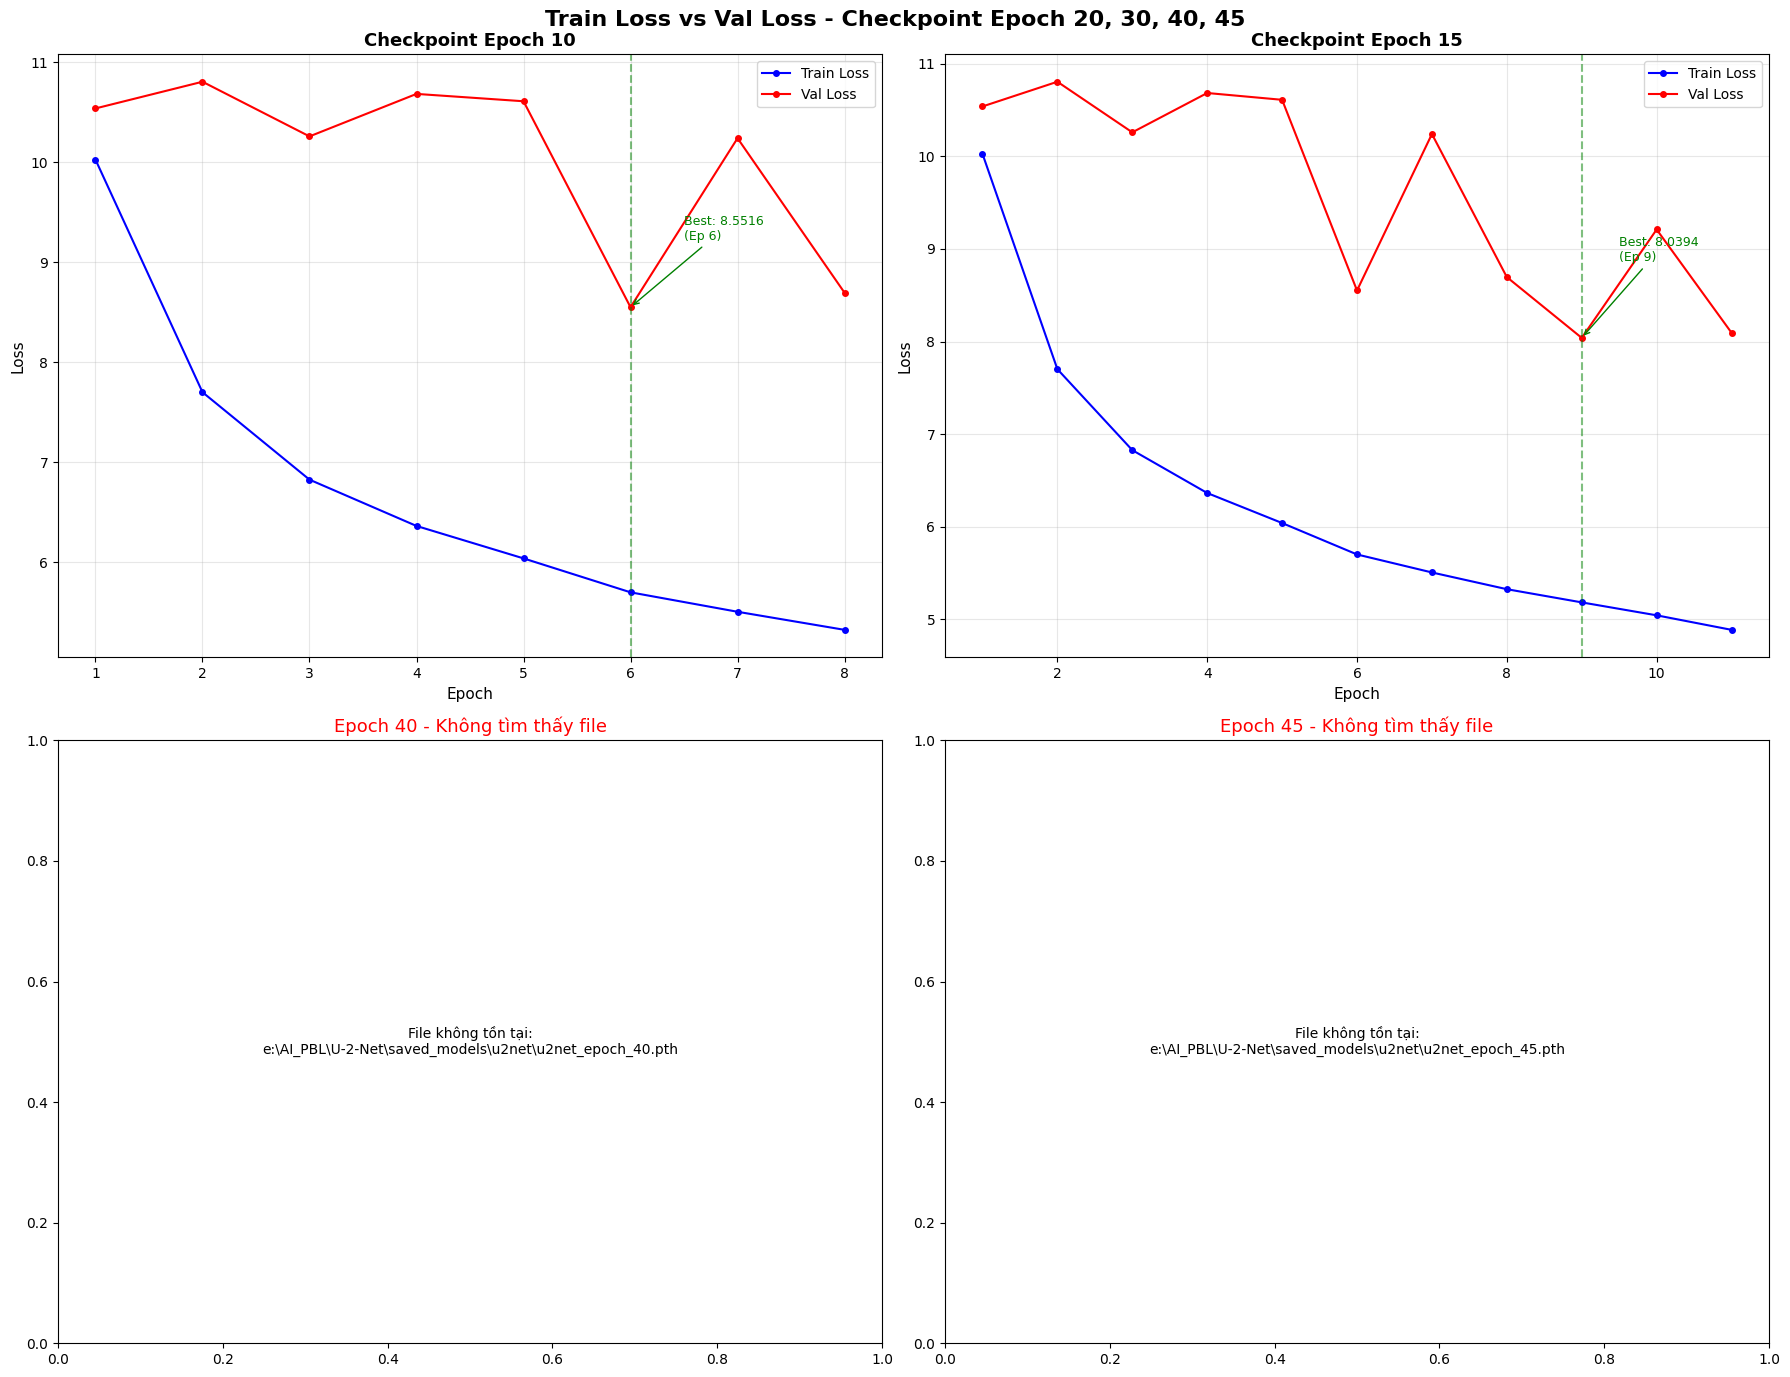


Biểu đồ đã lưu tại: e:\AI_PBL\U-2-Net\saved_models\u2net\loss_chart_checkpoints.png


In [ ]:
import torch
import matplotlib.pyplot as plt
import os

MODEL_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'saved_models', 'u2net')

# Danh sách checkpoint cần vẽ
checkpoint_epochs = [10,15, 40, 45]
checkpoint_files = {ep: os.path.join(MODEL_DIR, f'u2net_epoch_{ep}.pth') for ep in checkpoint_epochs}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (ep, path) in enumerate(checkpoint_files.items()):
    ax = axes[idx]

    if not os.path.exists(path):
        ax.set_title(f'Epoch {ep} - Không tìm thấy file', fontsize=13, color='red')
        ax.text(0.5, 0.5, f'File không tồn tại:\n{path}', ha='center', va='center', fontsize=10, transform=ax.transAxes)
        print(f'Không tìm thấy: {path}')
        continue

    ckpt = torch.load(path, map_location='cpu')
    train_losses = ckpt.get('train_losses_per_epoch', [])
    val_losses = ckpt.get('val_losses_per_epoch', [])

    if not train_losses and not val_losses:
        ax.set_title(f'Epoch {ep} - Không có dữ liệu loss', fontsize=13, color='red')
        print(f'Checkpoint epoch {ep} không chứa dữ liệu loss theo epoch.')
        continue

    # Vẽ Train Loss và Val Loss trên cùng 1 biểu đồ
    if train_losses:
        ax.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', markersize=4, label='Train Loss')
    if val_losses:
        ax.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', markersize=4, label='Val Loss')

    # Đánh dấu best val loss
    if val_losses:
        best_val_ep = val_losses.index(min(val_losses)) + 1
        best_val = min(val_losses)
        ax.axvline(x=best_val_ep, color='green', linestyle='--', alpha=0.5)
        ax.annotate(f'Best: {best_val:.4f}\n(Ep {best_val_ep})',
                    xy=(best_val_ep, best_val),
                    xytext=(best_val_ep + 0.5, best_val + (max(val_losses) - min(val_losses)) * 0.3),
                    arrowprops=dict(arrowstyle='->', color='green'),
                    fontsize=9, color='green')

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(f'Checkpoint Epoch {ep}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # In thông tin
    print(f'--- Checkpoint Epoch {ep} ---')
    if train_losses:
        print(f'  Train Loss cuối (epoch {len(train_losses)}): {train_losses[-1]:.4f}')
    if val_losses:
        print(f'  Val Loss cuối  (epoch {len(val_losses)}): {val_losses[-1]:.4f}')
        print(f'  Val Loss thấp nhất: {min(val_losses):.4f} (Epoch {best_val_ep})')

plt.suptitle('Train Loss vs Val Loss - Checkpoint Epoch 20, 30, 40, 45', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'loss_chart_checkpoints.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBiểu đồ đã lưu tại: {os.path.join(MODEL_DIR, "loss_chart_checkpoints.png")}')

## Biểu đồ Metrics theo Epoch

Chạy sau khi training hoàn tất để xem MAE, maxFβ và S-measure thay đổi qua từng epoch.


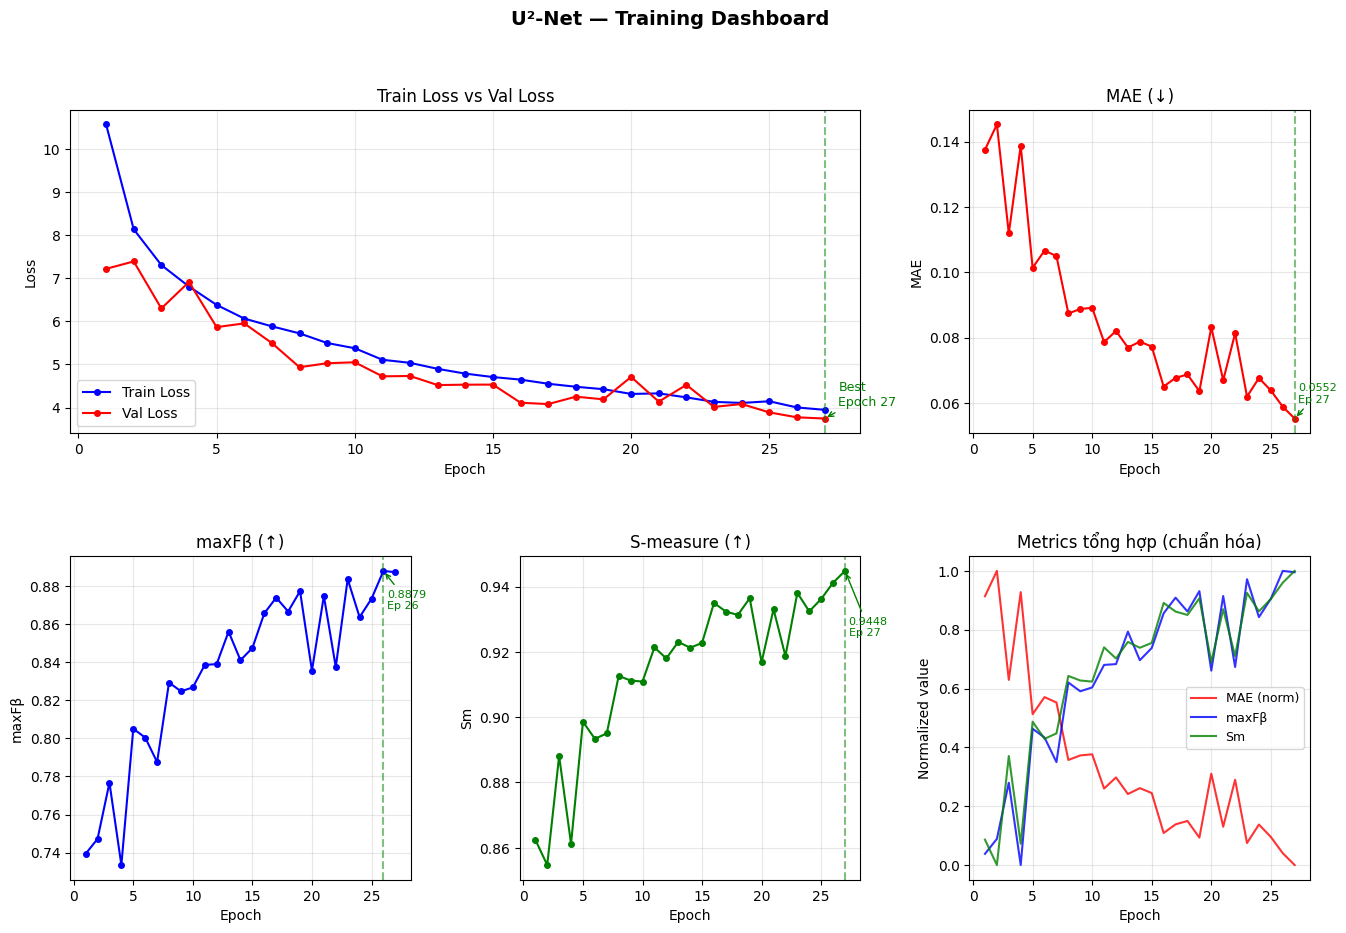


Biểu đồ đã lưu: e:\AI_PBL\U-2-Net\saved_models\u2net\metrics_per_epoch.png

Tóm tắt kết quả tốt nhất:
  MAE  thấp nhất : 0.0552  (Epoch 27)
  maxFβ cao nhất : 0.8879  (Epoch 26)
  Sm   cao nhất  : 0.9448  (Epoch 27)


In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def _hist_1d(values):
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        values = values.tolist()
    elif isinstance(values, tuple):
        values = list(values)
    if isinstance(values, list) and len(values) == 1 and isinstance(values[0], (list, tuple, np.ndarray)):
        values = np.asarray(values[0]).reshape(-1).tolist()
    return [float(v) for v in values if np.isscalar(v)]

def _load_history_from_checkpoint(ckpt_path):
    try:
        ckpt = torch.load(ckpt_path, map_location='cpu')
    except Exception as e:
        print(f'Không thể load checkpoint: {e}')
        return None

    if not isinstance(ckpt, dict):
        print('Checkpoint không chứa history dạng dict.')
        return None

    return {
        'train': _hist_1d(ckpt.get('train_losses_per_epoch', [])),
        'val': _hist_1d(ckpt.get('val_losses_per_epoch', [])),
        'mae': _hist_1d(ckpt.get('mae_per_epoch', [])),
        'maxf': _hist_1d(ckpt.get('maxF_per_epoch', [])),
        'sm': _hist_1d(ckpt.get('sm_per_epoch', [])),
    }

def _resolve_model_dir():
    if 'MODEL_DIR' in globals() and MODEL_DIR and os.path.isdir(MODEL_DIR):
        return MODEL_DIR
    project_dir = globals().get('PROJECT_DIR', os.getcwd())
    return os.path.join(project_dir, 'saved_models', 'u2net')

def _resolve_ckpt_path(model_dir):
    if not os.path.isdir(model_dir):
        return None

    # 1) Ưu tiên đúng checkpoint bạn resume trong notebook nếu tồn tại.
    resume_ckpt = globals().get('RESUME_CKPT')
    if isinstance(resume_ckpt, str) and resume_ckpt and os.path.exists(resume_ckpt):
        return resume_ckpt

    # 2) Ưu tiên checkpoint dừng tay cụ thể nếu có.
    stopped_ckpt = os.path.join(model_dir, 'u2net_stopped_at_iter_138086.pth')
    if os.path.exists(stopped_ckpt):
        return stopped_ckpt

    # 3) Nếu không có 2 file trên thì chọn checkpoint có history dài nhất.
    candidate_paths = []
    for name in os.listdir(model_dir):
        if name.endswith('.pth') and name.startswith('u2net'):
            candidate_paths.append(os.path.join(model_dir, name))

    if not candidate_paths:
        return None

    best_path = None
    best_score = -1
    for p in candidate_paths:
        hist = _load_history_from_checkpoint(p)
        if hist is None:
            continue
        score = len(hist['train']) + len(hist['val']) + len(hist['mae']) + len(hist['maxf']) + len(hist['sm'])
        if score > best_score:
            best_score = score
            best_path = p

    if best_path is not None:
        print(f'Đã chọn checkpoint có history dài nhất (score={best_score}).')
        return best_path

    # fallback cuối cùng
    for fallback in [
        os.path.join(model_dir, 'u2net_best.pth'),
        os.path.join(model_dir, 'u2net_final.pth'),
    ]:
        if os.path.exists(fallback):
            return fallback
    return None

# Ưu tiên lấy history trong RAM (nếu bạn vừa train xong).
train_hist = _hist_1d(globals().get('train_losses_per_epoch'))
val_hist = _hist_1d(globals().get('val_losses_per_epoch'))
mae_hist = _hist_1d(globals().get('mae_per_epoch'))
maxf_hist = _hist_1d(globals().get('maxF_per_epoch'))
sm_hist = _hist_1d(globals().get('sm_per_epoch'))

# Nếu thiếu dữ liệu trong RAM thì tự load từ checkpoint.
if len(train_hist) == 0:
    model_dir = _resolve_model_dir()
    ckpt_path = _resolve_ckpt_path(model_dir)
    if ckpt_path is not None:
        print(f'Không thấy history trong RAM, đang load từ checkpoint: {ckpt_path}')
        loaded = _load_history_from_checkpoint(ckpt_path)
        if loaded is not None:
            train_hist = loaded['train']
            val_hist = loaded['val']
            mae_hist = loaded['mae']
            maxf_hist = loaded['maxf']
            sm_hist = loaded['sm']
    else:
        print(f'Không tìm thấy checkpoint trong: {model_dir}')

epochs_r = range(1, len(train_hist) + 1)
has_metrics = len(train_hist) > 0 and len(mae_hist) > 0 and len(maxf_hist) > 0 and len(sm_hist) > 0

if has_metrics:
    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

    # 1. Train vs Val Loss
    ax0 = fig.add_subplot(gs[0, :2])
    ax0.plot(range(1, len(train_hist) + 1), train_hist, 'b-o', markersize=4, label='Train Loss')
    if val_hist:
        ax0.plot(range(1, len(val_hist) + 1), val_hist, 'r-o', markersize=4, label='Val Loss')
        _be = val_hist.index(min(val_hist)) + 1
        ax0.axvline(_be, color='green', linestyle='--', alpha=0.5)
        ax0.annotate(
            f'Best\nEpoch {_be}',
            xy=(_be, min(val_hist)),
            xytext=(_be + 0.5, min(val_hist) + 0.3),
            fontsize=9,
            color='green',
            arrowprops=dict(arrowstyle='->', color='green')
        )
    ax0.set_title('Train Loss vs Val Loss', fontsize=12)
    ax0.set_xlabel('Epoch')
    ax0.set_ylabel('Loss')
    ax0.legend()
    ax0.grid(True, alpha=0.3)

    # 2. MAE per epoch
    ax1 = fig.add_subplot(gs[0, 2])
    ax1.plot(range(1, len(mae_hist) + 1), mae_hist, 'r-o', markersize=4)
    ax1.set_title('MAE (↓)', fontsize=12)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('MAE')
    ax1.grid(True, alpha=0.3)
    _best_mae_ep = mae_hist.index(min(mae_hist)) + 1
    ax1.axvline(_best_mae_ep, color='green', linestyle='--', alpha=0.5)
    ax1.annotate(
        f'{min(mae_hist):.4f}\nEp {_best_mae_ep}',
        xy=(_best_mae_ep, min(mae_hist)),
        xytext=(_best_mae_ep + 0.3, min(mae_hist) + 0.005),
        fontsize=8,
        color='green',
        arrowprops=dict(arrowstyle='->', color='green')
    )

    # 3. maxFβ per epoch
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(range(1, len(maxf_hist) + 1), maxf_hist, 'b-o', markersize=4)
    ax2.set_title('maxFβ (↑)', fontsize=12)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('maxFβ')
    ax2.grid(True, alpha=0.3)
    _best_f_ep = maxf_hist.index(max(maxf_hist)) + 1
    ax2.axvline(_best_f_ep, color='green', linestyle='--', alpha=0.5)
    ax2.annotate(
        f'{max(maxf_hist):.4f}\nEp {_best_f_ep}',
        xy=(_best_f_ep, max(maxf_hist)),
        xytext=(_best_f_ep + 0.3, max(maxf_hist) - 0.02),
        fontsize=8,
        color='green',
        arrowprops=dict(arrowstyle='->', color='green')
    )

    # 4. S-measure per epoch
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(range(1, len(sm_hist) + 1), sm_hist, 'g-o', markersize=4)
    ax3.set_title('S-measure (↑)', fontsize=12)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Sm')
    ax3.grid(True, alpha=0.3)
    _best_sm_ep = sm_hist.index(max(sm_hist)) + 1
    ax3.axvline(_best_sm_ep, color='green', linestyle='--', alpha=0.5)
    ax3.annotate(
        f'{max(sm_hist):.4f}\nEp {_best_sm_ep}',
        xy=(_best_sm_ep, max(sm_hist)),
        xytext=(_best_sm_ep + 0.3, max(sm_hist) - 0.02),
        fontsize=8,
        color='green',
        arrowprops=dict(arrowstyle='->', color='green')
    )

    # 5. All metrics normalized on one axis
    ax4 = fig.add_subplot(gs[1, 2])
    def _norm(lst):
        a = np.array(lst)
        mn, mx = a.min(), a.max()
        return (a - mn) / (mx - mn + 1e-8)
    ax4.plot(range(1, len(mae_hist) + 1), _norm(mae_hist), 'r-', label='MAE (norm)', alpha=0.8)
    ax4.plot(range(1, len(maxf_hist) + 1), _norm(maxf_hist), 'b-', label='maxFβ', alpha=0.8)
    ax4.plot(range(1, len(sm_hist) + 1), _norm(sm_hist), 'g-', label='Sm', alpha=0.8)
    ax4.set_title('Metrics tổng hợp (chuẩn hóa)', fontsize=12)
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Normalized value')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    plt.suptitle('U²-Net — Training Dashboard', fontsize=14, fontweight='bold')
    chart_path = os.path.join(_resolve_model_dir(), 'metrics_per_epoch.png')
    plt.savefig(chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nBiểu đồ đã lưu: {chart_path}')
    print('\nTóm tắt kết quả tốt nhất:')
    print(f'  MAE  thấp nhất : {min(mae_hist):.4f}  (Epoch {mae_hist.index(min(mae_hist))+1})')
    print(f'  maxFβ cao nhất : {max(maxf_hist):.4f}  (Epoch {maxf_hist.index(max(maxf_hist))+1})')
    print(f'  Sm   cao nhất  : {max(sm_hist):.4f}  (Epoch {sm_hist.index(max(sm_hist))+1})')
else:
    print('Chưa có đủ dữ liệu metrics trong RAM/checkpoint để vẽ dashboard đầy đủ.')
    print('Mẹo: chạy xong training hoặc đảm bảo checkpoint có các key *_per_epoch.')
    fig, ax = plt.subplots(figsize=(10, 5))
    if train_hist:
        ax.plot(range(1, len(train_hist) + 1), train_hist, 'b-o', markersize=4, label='Train Loss')
    if val_hist:
        ax.plot(range(1, len(val_hist) + 1), val_hist, 'r-o', markersize=4, label='Val Loss')
    if train_hist or val_hist:
        ax.set_title('Train Loss vs Val Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()
    else:
        print('Không có train/val history để vẽ biểu đồ.')

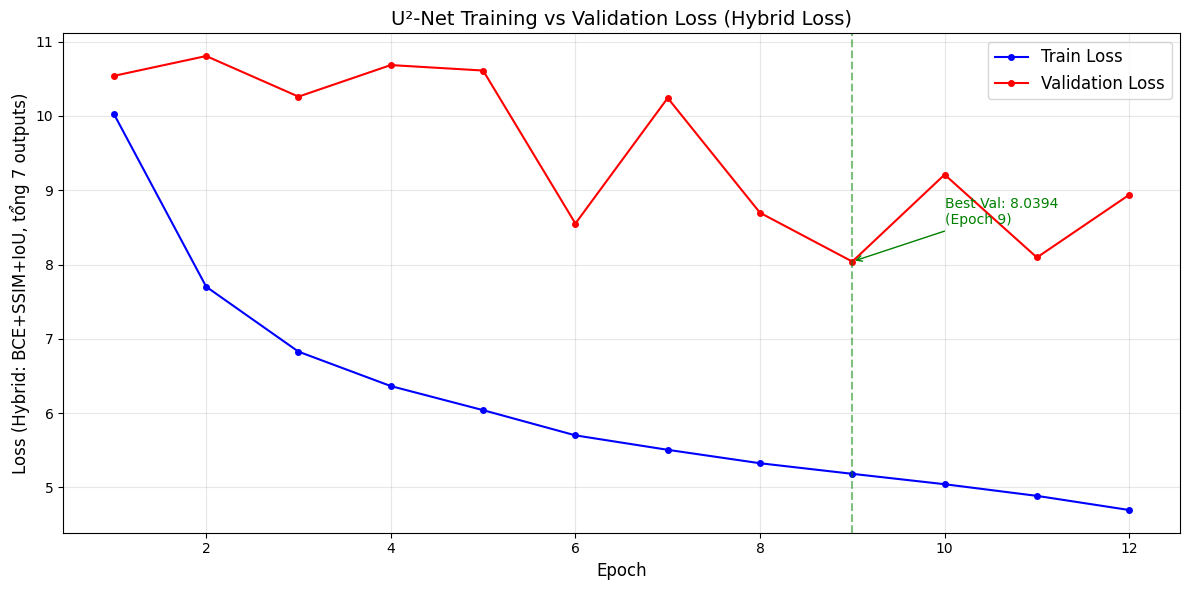


Biểu đồ đã lưu tại: e:\AI_PBL\U-2-Net\saved_models\u2net\loss_chart.png
Train Loss cuối:      4.6937
Val Loss cuối:        8.9389
Val Loss thấp nhất:   8.0394 (Epoch 9)


In [ ]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ Train Loss vs Validation Loss
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

epochs_range = range(1, len(train_losses_per_epoch) + 1)

ax.plot(epochs_range, train_losses_per_epoch, 'b-o', label='Train Loss', markersize=4)
ax.plot(epochs_range, val_losses_per_epoch, 'r-o', label='Validation Loss', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (Hybrid: BCE+SSIM+IoU, tổng 7 outputs)', fontsize=12)
ax.set_title('U²-Net Training vs Validation Loss (Hybrid Loss)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Đánh dấu epoch có val loss thấp nhất
if val_losses_per_epoch:
    best_epoch = val_losses_per_epoch.index(min(val_losses_per_epoch)) + 1
    best_val = min(val_losses_per_epoch)
    ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
    ax.annotate(f'Best Val: {best_val:.4f}\n(Epoch {best_epoch})',
                xy=(best_epoch, best_val),
                xytext=(best_epoch + 1, best_val + 0.5),
                arrowprops=dict(arrowstyle='->', color='green'),
                fontsize=10, color='green')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'loss_chart.png'), dpi=150)
plt.show()

print(f'\nBiểu đồ đã lưu tại: {os.path.join(MODEL_DIR, "loss_chart.png")}')
print(f'Train Loss cuối:      {train_losses_per_epoch[-1]:.4f}' if train_losses_per_epoch else '')
print(f'Val Loss cuối:        {val_losses_per_epoch[-1]:.4f}' if val_losses_per_epoch else '')
if val_losses_per_epoch:
    print(f'Val Loss thấp nhất:   {min(val_losses_per_epoch):.4f} (Epoch {val_losses_per_epoch.index(min(val_losses_per_epoch))+1})')


In [116]:
# Chạy cell này SAU KHI bạn nhấn nút 'Stop' trên cell training để lưu khẩn cấp
current_epoch = int(epoch + 1) if 'epoch' in globals() else int(globals().get('start_epoch', 0))
current_iter = int(globals().get('ite_num', 0))
current_loss = (running_loss / ite_num4val) if ('ite_num4val' in globals() and ite_num4val > 0) else 0.0
current_lr = float(optimizer.param_groups[0]['lr']) if 'optimizer' in globals() else None

save_path = os.path.join(MODEL_DIR, MODEL_NAME + "_stopped_at_iter_%d.pth" % current_iter)

torch.save({
    'epoch': current_epoch,
    'ite_num': current_iter,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_type': SCHEDULER_TYPE,
    'loss': current_loss,
    'train_losses_per_epoch': list(globals().get('train_losses_per_epoch', [])),
    'val_losses_per_epoch': list(globals().get('val_losses_per_epoch', [])),
    'mae_per_epoch': list(globals().get('mae_per_epoch', [])),
    'maxF_per_epoch': list(globals().get('maxF_per_epoch', [])),
    'sm_per_epoch': list(globals().get('sm_per_epoch', [])),
    'lr_per_epoch': list(globals().get('lr_per_epoch', [])),
    'best_val_loss': float(globals().get('best_val_loss', float('inf'))),
    'early_stop_counter': int(globals().get('early_stop_counter', 0)),
    'current_lr': current_lr,
}, save_path)

print(f'Đã lưu checkpoint dừng khẩn cấp tại: {save_path}')
print(f'Để tiếp tục train, hãy đặt RESUME_CKPT = "{save_path}"')
print(f'History lengths | train={len(globals().get("train_losses_per_epoch", []))}, val={len(globals().get("val_losses_per_epoch", []))}, mae={len(globals().get("mae_per_epoch", []))}, maxF={len(globals().get("maxF_per_epoch", []))}, sm={len(globals().get("sm_per_epoch", []))}, lr={len(globals().get("lr_per_epoch", []))}')

Đã lưu checkpoint dừng khẩn cấp tại: e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_stopped_at_iter_88263.pth
Để tiếp tục train, hãy đặt RESUME_CKPT = "e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_stopped_at_iter_88263.pth"
History lengths | train=14, val=14, mae=14, maxF=14, sm=14, lr=14


## Bước 7: Lưu model cuối cùng

In [ ]:
# Luu checkpoint cuoi cung (day du metrics/history de resume + ve bieu do)
final_save_path = os.path.join(MODEL_DIR, f'{MODEL_NAME}_final.pth')
final_weights_path = os.path.join(MODEL_DIR, f'{MODEL_NAME}_final_weights.pth')

checkpoint_payload = {
    'epoch': int(globals().get('EPOCH_NUM', 0)),
    'ite_num': int(globals().get('ite_num', 0)),
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict() if 'optimizer' in globals() else None,
    'scheduler_type': globals().get('SCHEDULER_TYPE', None),
    'train_losses_per_epoch': list(globals().get('train_losses_per_epoch', [])),
    'val_losses_per_epoch': list(globals().get('val_losses_per_epoch', [])),
    'mae_per_epoch': list(globals().get('mae_per_epoch', [])),
    'maxF_per_epoch': list(globals().get('maxF_per_epoch', [])),
    'sm_per_epoch': list(globals().get('sm_per_epoch', [])),
    'lr_per_epoch': list(globals().get('lr_per_epoch', [])),
    'best_val_loss': float(globals().get('best_val_loss', float('inf'))),
    'early_stop_counter': int(globals().get('early_stop_counter', 0)),
    'current_lr': float(optimizer.param_groups[0]['lr']) if 'optimizer' in globals() else None,
}

torch.save(checkpoint_payload, final_save_path)
torch.save(net.state_dict(), final_weights_path)

print(f'Da luu final checkpoint (co metrics): {final_save_path}')
print(f'Da luu final weights-only: {final_weights_path}')
print(
    f'History lengths | train={len(checkpoint_payload["train_losses_per_epoch"])}, '
    f'val={len(checkpoint_payload["val_losses_per_epoch"])}, '
    f'mae={len(checkpoint_payload["mae_per_epoch"])}, '
    f'maxF={len(checkpoint_payload["maxF_per_epoch"])}, '
    f'sm={len(checkpoint_payload["sm_per_epoch"])}, '
    f'lr={len(checkpoint_payload["lr_per_epoch"])}'
 )

# Copy len Drive neu co
if DRIVE_SAVE_DIR:
    try:
        import shutil
        shutil.copy2(final_save_path, os.path.join(DRIVE_SAVE_DIR, f'{MODEL_NAME}_final.pth'))
        shutil.copy2(final_weights_path, os.path.join(DRIVE_SAVE_DIR, f'{MODEL_NAME}_final_weights.pth'))
        print(f'Da copy len Google Drive: {DRIVE_SAVE_DIR}')
    except Exception as e:
        print(f'Loi copy len Drive: {e}')

Da luu final checkpoint (co metrics): e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_final.pth
Da luu final weights-only: e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_final_weights.pth
History lengths | train=12, val=12, mae=12, maxF=12, sm=12, lr=12


## Bước 8: Đánh giá model theo metrics trong bài báo U²-Net

Bài báo **Qin et al. (Pattern Recognition 2020)** đánh giá model bằng các metrics chuẩn cho Salient Object Detection:

| Metric | Ký hiệu | Tốt khi | Mô tả |
|--------|---------|---------|-------|
| Mean Absolute Error | MAE (↓) | Gần 0 | Sai số pixel-wise trung bình giữa predicted map và GT |
| Max F-measure | maxFβ (↑) | Gần 1 | Max F-score qua 255 ngưỡng, β²=0.3 |
| Mean F-measure | meanFβ (↑) | Gần 1 | Trung bình F-score qua 255 ngưỡng |
| S-measure | Sm (↑) | Gần 1 | Đánh giá structural similarity (Fan et al. ICCV 2017) |
| E-measure | Em (↑) | Gần 1 | Enhanced alignment measure (Fan et al. IJCAI 2018) |
| Weighted F-measure | Fβw (↑) | Gần 1 | F-measure có trọng số theo độ quan trọng pixel |

> Cell bên dưới chạy evaluation trên **tập validation (20%)** sử dụng model best đã lưu.  
> Để đánh giá đúng chuẩn paper, nên chạy trên tập test riêng (DUTS-TE).

Đã load model từ: e:\AI_PBL\U-2-Net\saved_models\u2net\u2net_epoch_30.pth
Dùng tập validation đã chia (2111 ảnh)

Bắt đầu inference và tính metrics...
  [100/2111] MAE=0.0605 | maxF=0.9214 | Sm=0.9144
  [200/2111] MAE=0.0543 | maxF=0.9333 | Sm=0.9276
  [300/2111] MAE=0.0540 | maxF=0.9344 | Sm=0.9271
  [400/2111] MAE=0.0556 | maxF=0.9347 | Sm=0.9254
  [500/2111] MAE=0.0561 | maxF=0.9374 | Sm=0.9254
  [600/2111] MAE=0.0568 | maxF=0.9353 | Sm=0.9230
  [700/2111] MAE=0.0558 | maxF=0.9351 | Sm=0.9226
  [800/2111] MAE=0.0553 | maxF=0.9353 | Sm=0.9241
  [900/2111] MAE=0.0554 | maxF=0.9331 | Sm=0.9239
  [1000/2111] MAE=0.0559 | maxF=0.9328 | Sm=0.9236
  [1100/2111] MAE=0.0561 | maxF=0.9326 | Sm=0.9238
  [1200/2111] MAE=0.0560 | maxF=0.9328 | Sm=0.9239
  [1300/2111] MAE=0.0556 | maxF=0.9329 | Sm=0.9242
  [1400/2111] MAE=0.0574 | maxF=0.9305 | Sm=0.9221
  [1500/2111] MAE=0.0575 | maxF=0.9291 | Sm=0.9217
  [1600/2111] MAE=0.0567 | maxF=0.9298 | Sm=0.9230
  [1700/2111] MAE=0.0560 | maxF=0.9307 | S

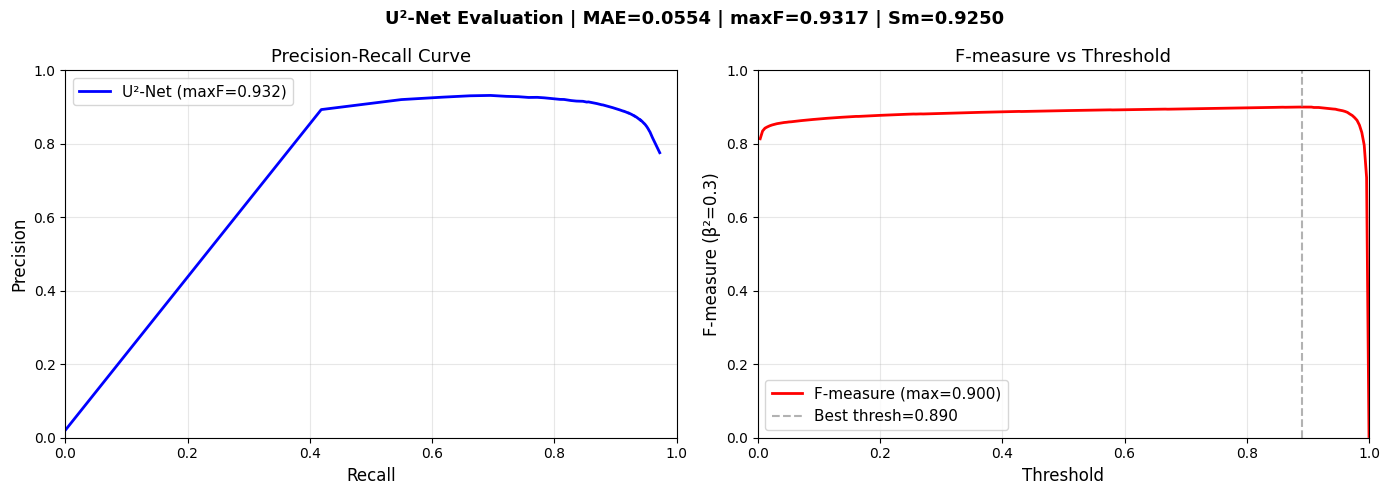


Biểu đồ đã lưu tại: e:\AI_PBL\U-2-Net\saved_models\u2net\eval_metrics_chart.png


In [ ]:
# ============================================================
# ĐÁNH GIÁ MODEL THEO METRICS TRONG BÀI BÁO U²-Net
# Qin et al., Pattern Recognition 2020
# Metrics: MAE, maxFβ, meanFβ, S-measure, E-measure, Weighted-F
# ============================================================
import torch
import torch.nn as nn
import numpy as np
import os
import glob
import sys
from PIL import Image
import torchvision.transforms as transforms
from torch.autograd import Variable
import matplotlib.pyplot as plt
import matplotlib
from scipy.ndimage import convolve

# ---- 0. Load model ----
EVAL_CKPT = os.path.join(PROJECT_DIR, 'saved_models', 'u2net', 'u2net_epoch_30.pth')  # <-- đổi path nếu cần

sys.path.insert(0, PROJECT_DIR)
from model import U2NET, U2NETP
from data_loader import RescaleT, ToTensorLab, SalObjDataset

eval_model_name = 'u2net'  # hoặc 'u2netp'
eval_net = U2NET(3, 1) if eval_model_name == 'u2net' else U2NETP(3, 1)

if os.path.exists(EVAL_CKPT):
    ckpt = torch.load(EVAL_CKPT, map_location='cpu')
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        eval_net.load_state_dict(ckpt['model_state_dict'])
    else:
        eval_net.load_state_dict(ckpt)
    print(f'Đã load model từ: {EVAL_CKPT}')
else:
    print(f'CẢNH BÁO: Không tìm thấy {EVAL_CKPT}')
    print('Dùng model đang có trong memory (net) để đánh giá...')
    eval_net = net  # fallback dùng model đang train

device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_net = eval_net.to(device)
eval_net.eval()

# ============================================================
# ---- 1. Định nghĩa các hàm tính metrics ----
# ============================================================

def compute_mae(pred, gt):
    """Mean Absolute Error - metric chính trong bài báo U²-Net"""
    return float(np.mean(np.abs(pred.astype(np.float64) - gt.astype(np.float64))))


def compute_f_measure_curve(pred, gt, beta2=0.3, num_thresh=255):
    """
    Tính F-measure curve qua 255 ngưỡng (0~255).
    Trả về: precisions, recalls, f_measures, max_f, mean_f
    β² = 0.3 theo Achanta et al. (chuẩn bài báo U²-Net)
    """
    pred_uint8 = (pred * 255).astype(np.uint8)
    gt_binary  = (gt >= 0.5).astype(np.float64)
    gt_sum = gt_binary.sum()

    precisions, recalls, f_measures = [], [], []
    for thresh in range(1, num_thresh + 1):
        pred_bin = (pred_uint8 >= thresh).astype(np.float64)
        tp = (pred_bin * gt_binary).sum()
        prec = tp / (pred_bin.sum() + 1e-8)
        rec  = tp / (gt_sum + 1e-8)
        f = (1 + beta2) * prec * rec / (beta2 * prec + rec + 1e-8)
        precisions.append(prec)
        recalls.append(rec)
        f_measures.append(f)

    precisions  = np.array(precisions)
    recalls     = np.array(recalls)
    f_measures  = np.array(f_measures)
    return precisions, recalls, f_measures, f_measures.max(), f_measures.mean()


def compute_s_measure(pred, gt, alpha=0.5):
    """
    S-measure (Structure Measure) - Fan et al. ICCV 2017
    S = alpha * S_o + (1 - alpha) * S_r
    """
    def _object_score(pred, gt):
        """Object-aware structural similarity"""
        gt = gt.astype(np.float64)
        pred = pred.astype(np.float64)
        fg = pred * gt
        bg = (1 - pred) * (1 - gt)
        u = gt.mean()
        if u == 0:
            return 1 - pred.mean()
        if u == 1:
            return pred.mean()
        # Foreground similarity
        x = fg[gt > 0]
        o_fg = 2 * x.mean() / (x.mean()**2 + 1.0 + 1e-8) if len(x) > 0 else 0.0
        # Background similarity
        y = bg[gt == 0]
        o_bg = 2 * y.mean() / (y.mean()**2 + 1.0 + 1e-8) if len(y) > 0 else 0.0
        return u * o_fg + (1 - u) * o_bg

    def _region_score(pred, gt):
        """Region-aware structural similarity"""
        H, W = gt.shape
        gt = gt.astype(np.float64)
        pred = pred.astype(np.float64)
        # Centroid of GT
        ys, xs = np.where(gt > 0.5)
        if len(xs) == 0:
            return 1.0 - pred.mean()
        cx = int(xs.mean())
        cy = int(ys.mean())
        # Split into 4 quadrants
        def _ssim_quad(p, g):
            if p.size == 0 or g.size == 0:
                return 0.0, 0
            pm, gm = p.mean(), g.mean()
            pv = p.var() + 1e-8
            gv = g.var() + 1e-8
            cov = ((p - pm) * (g - gm)).mean()
            ssim = (2 * pm * gm + 1e-8) * (2 * cov + 1e-8) / \
                   ((pm**2 + gm**2 + 1e-8) * (pv + gv + 1e-8))
            return ssim, p.size
        q1_s, n1 = _ssim_quad(pred[:cy, :cx],   gt[:cy, :cx])
        q2_s, n2 = _ssim_quad(pred[:cy, cx:],   gt[:cy, cx:])
        q3_s, n3 = _ssim_quad(pred[cy:, :cx],   gt[cy:, :cx])
        q4_s, n4 = _ssim_quad(pred[cy:, cx:],   gt[cy:, cx:])
        total = n1 + n2 + n3 + n4
        if total == 0:
            return 0.0
        return (n1*q1_s + n2*q2_s + n3*q3_s + n4*q4_s) / total

    pred_f = pred.astype(np.float64)
    gt_f   = gt.astype(np.float64)
    so = _object_score(pred_f, gt_f)
    sr = _region_score(pred_f, gt_f)
    return alpha * so + (1 - alpha) * sr


def compute_e_measure(pred, gt):
    """
    Enhanced Alignment Measure (E-measure) - Fan et al. IJCAI 2018
    Dùng ngưỡng adaptive (mean*2)
    """
    pred_f = pred.astype(np.float64)
    gt_f   = gt.astype(np.float64)
    # Adaptive threshold
    thresh = min(pred_f.mean() * 2, 1.0)
    pred_bin = (pred_f >= thresh).astype(np.float64)
    # Align matrix
    mu_p = pred_bin.mean()
    mu_g = gt_f.mean()
    align_p = pred_bin - mu_p
    align_g = gt_f   - mu_g
    align_mat = 2.0 * align_p * align_g / (align_p**2 + align_g**2 + 1e-8)
    enhanced = ((align_mat + 1)**2) / 4.0
    H, W = gt_f.shape
    return float(enhanced.sum() / (H * W - 1 + 1e-8))


def compute_weighted_f(pred, gt, beta2=1.0):
    """
    Weighted F-measure (Fβw) - Margolin et al.
    Gán trọng số theo khoảng cách đến biên GT để phạt nặng sai lầm ở vùng edge
    """
    pred_f = pred.astype(np.float64)
    gt_f   = (gt >= 0.5).astype(np.float64)
    # Tính weight map từ distance transform
    from scipy.ndimage import distance_transform_edt
    dst = distance_transform_edt(1 - gt_f)
    dst_norm = dst / (dst.max() + 1e-8)
    weight = 1.0 - dst_norm   # trọng số cao ở biên (edge)
    # Weighted TP, FP, FN
    tp_w  = (weight * pred_f * gt_f).sum()
    fp_w  = (weight * pred_f * (1 - gt_f)).sum()
    fn_w  = (weight * (1 - pred_f) * gt_f).sum()
    prec  = tp_w / (tp_w + fp_w + 1e-8)
    rec   = tp_w / (tp_w + fn_w + 1e-8)
    f_w   = (1 + beta2) * prec * rec / (beta2 * prec + rec + 1e-8)
    return float(f_w)


# ============================================================
# ---- 2. Inference và tính metrics trên tập Validation ----
# ============================================================

# DataLoader val (dùng lại val_img_list, val_lbl_list từ Bước 5)
# Nếu chưa có, tự lấy 20% dataset
try:
    _ = val_img_list
    print(f'Dùng tập validation đã chia ({len(val_img_list)} ảnh)')
except NameError:
    import glob
    from sklearn.model_selection import train_test_split
    all_imgs = glob.glob(os.path.join(DATA_DIR, TRA_IMAGE_DIR, '*.jpg'))
    all_lbls = [os.path.join(DATA_DIR, TRA_LABEL_DIR,
                             os.path.splitext(os.path.basename(p))[0] + '.png')
                for p in all_imgs]
    _, val_img_list, _, val_lbl_list = train_test_split(
        all_imgs, all_lbls, test_size=0.2, random_state=42)
    print(f'Tạo lại tập validation ({len(val_img_list)} ảnh)')

print('\nBắt đầu inference và tính metrics...')

all_mae, all_maxF, all_meanF, all_sm, all_em, all_wf = [], [], [], [], [], []
all_precisions = np.zeros(255)
all_recalls    = np.zeros(255)

transform_eval = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

with torch.no_grad():
    for idx, (img_path, lbl_path) in enumerate(zip(val_img_list, val_lbl_list)):
        # Load ảnh
        img = Image.open(img_path).convert('RGB')
        inp = transform_eval(img).unsqueeze(0).to(device)

        # Load GT mask
        if not os.path.exists(lbl_path):
            continue
        gt_pil = Image.open(lbl_path).convert('L')

        # Inference
        d0, *_ = eval_net(inp)
        pred_tensor = d0.squeeze().cpu()
        # Resize pred về kích thước GT gốc
        pred_pil = transforms.ToPILImage()(pred_tensor).resize(gt_pil.size, Image.BILINEAR)

        pred_np = np.array(pred_pil).astype(np.float64) / 255.0
        gt_np   = np.array(gt_pil).astype(np.float64)   / 255.0

        # Tính từng metric
        mae = compute_mae(pred_np, gt_np)
        precs, recs, fms, max_f, mean_f = compute_f_measure_curve(pred_np, gt_np)
        sm  = compute_s_measure(pred_np, gt_np)
        em  = compute_e_measure(pred_np, gt_np)
        wf  = compute_weighted_f(pred_np, gt_np)

        all_mae.append(mae)
        all_maxF.append(max_f)
        all_meanF.append(mean_f)
        all_sm.append(sm)
        all_em.append(em)
        all_wf.append(wf)
        all_precisions += precs
        all_recalls    += recs

        if (idx + 1) % 100 == 0:
            print(f'  [{idx+1}/{len(val_img_list)}] MAE={np.mean(all_mae):.4f} | '
                  f'maxF={np.mean(all_maxF):.4f} | Sm={np.mean(all_sm):.4f}')

n = len(all_mae)
avg_mae   = np.mean(all_mae)
avg_maxF  = np.mean(all_maxF)
avg_meanF = np.mean(all_meanF)
avg_sm    = np.mean(all_sm)
avg_em    = np.mean(all_em)
avg_wf    = np.mean(all_wf)
avg_precs = all_precisions / n
avg_recs  = all_recalls    / n

print('\n' + '='*60)
print(f'  KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION ({n} ảnh)')
print('='*60)
print(f'  MAE        (↓): {avg_mae:.4f}  (paper U2Net DUTS-TE: 0.044)')
print(f'  maxFβ      (↑): {avg_maxF:.4f}  (paper U2Net DUTS-TE: 0.873)')
print(f'  meanFβ     (↑): {avg_meanF:.4f}')
print(f'  S-measure  (↑): {avg_sm:.4f}')
print(f'  E-measure  (↑): {avg_em:.4f}')
print(f'  Weighted-F (↑): {avg_wf:.4f}')
print('='*60)
print('  Lưu ý: Đánh giá trên val 20% của DUTS-TR, không phải DUTS-TE.')
print('  Để so sánh đúng với paper, chạy trên tập DUTS-TE riêng biệt.')

# ============================================================
# ---- 3. Vẽ PR Curve ----
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
axes[0].plot(avg_recs, avg_precs, 'b-', linewidth=2, label=f'U²-Net (maxF={avg_maxF:.3f})')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

# F-measure vs Threshold curve
thresholds = np.linspace(1/255, 1.0, 255)
# Tính F qua các ngưỡng từ avg P/R
beta2 = 0.3
fms_curve = (1 + beta2) * avg_precs * avg_recs / (beta2 * avg_precs + avg_recs + 1e-8)
axes[1].plot(thresholds, fms_curve, 'r-', linewidth=2,
             label=f'F-measure (max={fms_curve.max():.3f})')
axes[1].axvline(x=thresholds[fms_curve.argmax()], color='gray',
                linestyle='--', alpha=0.6, label=f'Best thresh={thresholds[fms_curve.argmax()]:.3f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('F-measure (β²=0.3)', fontsize=12)
axes[1].set_title('F-measure vs Threshold', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'U²-Net Evaluation | MAE={avg_mae:.4f} | maxF={avg_maxF:.4f} | Sm={avg_sm:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()

chart_path = os.path.join(MODEL_DIR, 'eval_metrics_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nBiểu đồ đã lưu tại: {chart_path}')

## (Tùy chọn) Chạy inference để kiểm tra model

e:\AI_PBL\U-2-Net\model\u2net.py:23: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  src = F.upsample(src,size=tar.shape[2:],mode='bilinear')


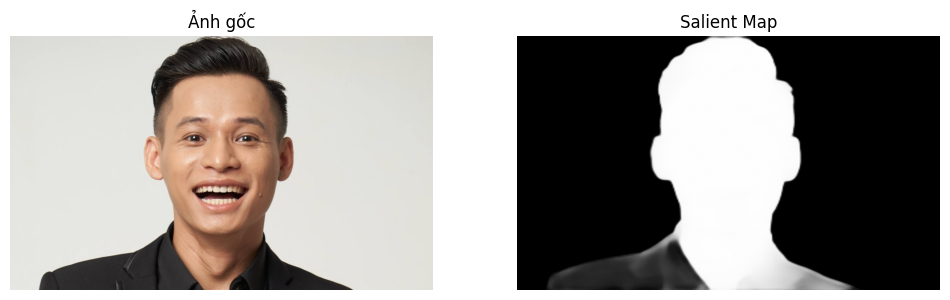

In [ ]:
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch, sys
sys.path.insert(0, PROJECT_DIR)
from model import U2NET

def predict(image_path, model, device):
    img = Image.open(image_path).convert('RGB')
    orig_size = img.size
    transform = transforms.Compose([
        transforms.Resize((320, 320)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    inp = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        d0, *_ = model(inp)
    pred = d0.squeeze().cpu().numpy()
    pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)
    mask = Image.fromarray((pred * 255).astype(np.uint8)).resize(orig_size)
    return img, mask

# Chỉnh đường dẫn ảnh test
TEST_IMAGE = os.path.join(PROJECT_DIR, 'test_data', 'test_images', 'img_8.webp')  # <-- Chỉnh lại

if os.path.exists(TEST_IMAGE):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    img, mask = predict(TEST_IMAGE, net, device)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img); axes[0].set_title('Ảnh gốc'); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Salient Map'); axes[1].axis('off')
    plt.show()
else:
    print(f'Không tìm thấy ảnh test: {TEST_IMAGE}')
    print('Hãy chỉnh lại đường dẫn TEST_IMAGE.')